In [6]:

import os

print(os.getcwd())
print(os.listdir())

C:\Users\PC\ml\results
['.ipynb_checkpoints', 'best_model_predictions.png', 'history.csv', 'metrics.csv', 'model_predictionsManual GRU.png', 'model_predictionsManual LSTM.png', 'model_predictionsManual RNN.png', 'model_predictionsPyTorch GRU.png', 'model_predictionsPyTorch LSTM.png', 'model_predictionsPyTorch RNN.png', 'validation_loss.png']


Используемое устройство: cpu

Файл изображений: train-images-idx3-ubyte.gz
Magic number: 2051
Количество изображений: 60000
Размер изображения: 28 x 28

Файл меток: train-labels-idx1-ubyte.gz
Magic number: 2049
Количество меток: 60000

Файл изображений: t10k-images-idx3-ubyte.gz
Magic number: 2051
Количество изображений: 10000
Размер изображения: 28 x 28

Файл меток: t10k-labels-idx1-ubyte.gz
Magic number: 2049
Количество меток: 10000

Epoch [1/5] Train Loss: 0.2446 Test Loss: 0.0881 Accuracy: 0.9726
Epoch [2/5] Train Loss: 0.0711 Test Loss: 0.0622 Accuracy: 0.9800
Epoch [3/5] Train Loss: 0.0487 Test Loss: 0.0456 Accuracy: 0.9855
Epoch [4/5] Train Loss: 0.0396 Test Loss: 0.0434 Accuracy: 0.9852
Epoch [5/5] Train Loss: 0.0316 Test Loss: 0.0386 Accuracy: 0.9866


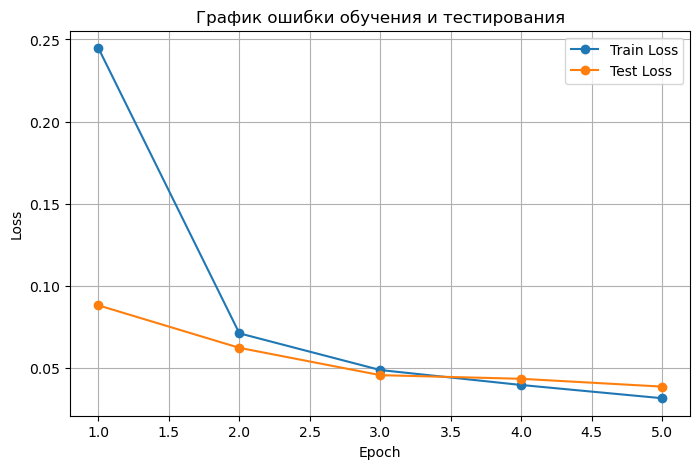

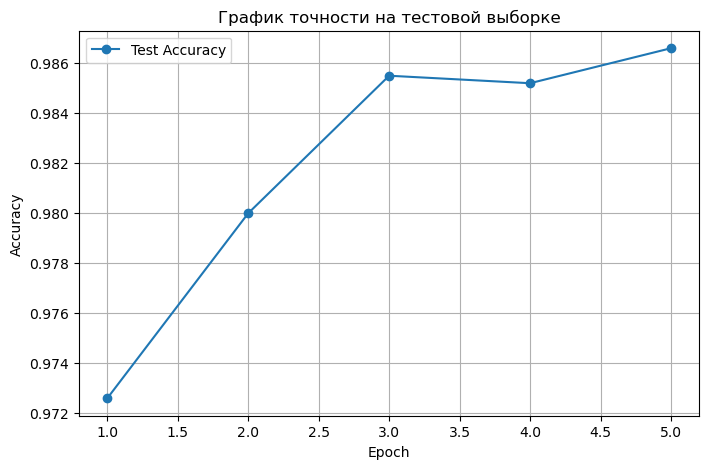

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score


BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_IMAGES_PATH = "train-images-idx3-ubyte.gz"
TRAIN_LABELS_PATH = "train-labels-idx1-ubyte.gz"

TEST_IMAGES_PATH = "t10k-images-idx3-ubyte.gz"
TEST_LABELS_PATH = "t10k-labels-idx1-ubyte.gz"


def read_images_from_gzip(filename):
    with gzip.open(filename, "rb") as f:
        magic_number = int.from_bytes(f.read(4), byteorder="big")
        number_of_images = int.from_bytes(f.read(4), byteorder="big")
        rows = int.from_bytes(f.read(4), byteorder="big")
        cols = int.from_bytes(f.read(4), byteorder="big")

        print("Файл изображений:", filename)
        print("Magic number:", magic_number)
        print("Количество изображений:", number_of_images)
        print("Размер изображения:", rows, "x", cols)
        print()

        image_data = f.read()
        images = np.frombuffer(image_data, dtype=np.uint8)
        images = images.reshape(number_of_images, rows, cols)

        return images


def read_labels_from_gzip(filename):
    with gzip.open(filename, "rb") as f:
        magic_number = int.from_bytes(f.read(4), byteorder="big")
        number_of_labels = int.from_bytes(f.read(4), byteorder="big")

        print("Файл меток:", filename)
        print("Magic number:", magic_number)
        print("Количество меток:", number_of_labels)
        print()

        label_data = f.read()
        labels = np.frombuffer(label_data, dtype=np.uint8)

        return labels


def print_image_to_console(image):
    for row in image:
        for pixel in row:
            if pixel < 128:
                print(".", end="")
            else:
                print("#", end="")
        print()


class MNISTDataset(Dataset):

    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

        self.images = self.images.unsqueeze(1)

        self.images = self.images / 255.0

        self.images = (self.images - 0.1307) / 0.3081

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        return image, label


def get_data_loaders():
    train_images = read_images_from_gzip(TRAIN_IMAGES_PATH)
    train_labels = read_labels_from_gzip(TRAIN_LABELS_PATH)

    test_images = read_images_from_gzip(TEST_IMAGES_PATH)
    test_labels = read_labels_from_gzip(TEST_LABELS_PATH)

    # ====================

    train_dataset = MNISTDataset(train_images, train_labels)
    test_dataset = MNISTDataset(test_images, test_labels)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_loader, test_loader


class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.ZeroPad2d(2),

            nn.Conv2d(
                in_channels=1,
                out_channels=6,
                kernel_size=5
            ),
            nn.Tanh(),

            nn.AvgPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=6,
                out_channels=16,
                kernel_size=5
            ),
            nn.Tanh(),

            nn.AvgPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),

            nn.Linear(120, 84),
            nn.Tanh(),

            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


def train_model(model, train_loader, criterion, optimizer):
    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    return average_loss


def evaluate_model(model, test_loader, criterion):
    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    average_loss = total_loss / len(test_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    return average_loss, accuracy


def plot_metrics(train_losses, test_losses, test_accuracies):
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
    plt.plot(epochs_range, test_losses, marker="o", label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("График ошибки обучения и тестирования")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, test_accuracies, marker="o", label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("График точности на тестовой выборке")
    plt.legend()
    plt.grid(True)
    plt.show()


def main():
    print("Используемое устройство:", DEVICE)
    print()

    train_loader, test_loader = get_data_loaders()

    model = LeNet5().to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    test_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        train_loss = train_model(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_accuracy = evaluate_model(
            model,
            test_loader,
            criterion
        )

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Accuracy: {test_accuracy:.4f}"
        )

    plot_metrics(
        train_losses,
        test_losses,
        test_accuracies
    )


if __name__ == "__main__":
    main()